In [28]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Load both claims files
claims1 = pd.read_csv('/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/claims_staged_cmu_1_2.csv')
claims2 = pd.read_csv('/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/claims_staged_cmu_2_2.csv')

# Combine into one dataframe
claims = pd.concat([claims1, claims2], ignore_index=True)

print(f"Claims 1 shape: {claims1.shape}")
print(f"Claims 2 shape: {claims2.shape}")
print(f"Combined Claims shape: {claims.shape}")
claims.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Claims 1 shape: (1258694, 24)
Claims 2 shape: (1258693, 24)
Combined Claims shape: (2517387, 24)


,PRI_DIAG_CD,ADM_DIAG_CD,DIAG_CD_001,DIAG_CD_002,DIAG_CD_003,HCPCS,DRG,Med_Cost_Category,NDC_CD,DRUG_NM,...,provider_number,ROUTE DESCRIPTION,STRENGTH DESCRIPTION,PROC_DESC,DIAG_DESC,DRG_DESC,ADM_DIAG_DESC,DIAG_001_DIAG_DESC,DIAG_002_DIAG_DESC,DIAG_003_DIAG_DESC
0,J431,NaN,NaN,NaN,NaN,94727,NaN,Prof PCP Procedures,NaN,NaN,...,NaN,NaN,NaN,Pulm function test by gas,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
1,J431,NaN,NaN,NaN,NaN,94060,NaN,Prof PCP Procedures,NaN,NaN,...,NaN,NaN,NaN,Evaluation of wheezing,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
2,J431,NaN,NaN,NaN,NaN,94060,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Evaluation of wheezing,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
3,J431,NaN,NaN,NaN,NaN,94726,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Pulm funct tst plethysmograp,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
4,J431,NaN,NaN,NaN,NaN,94729,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Co/membane diffuse capacity,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN


In [29]:
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/'

# Raw files
claims_1 = pd.read_csv(BASE + 'claims_staged_cmu_1_2.csv')
claims_2 = pd.read_csv(BASE + 'claims_staged_cmu_2_2.csv')
staging_raw = pd.read_csv(BASE + 'staging_dataset_cmu 1.csv')

In [30]:
# Merge claims
claims = pd.concat([claims_1, claims_2], ignore_index=True)

# Drop sparse columns
claims.drop(columns=['DRG_DESC', 'DRG', 'ADM_DIAG_DESC', 'ADM_DIAG_CD'], inplace=True)

# Type fixes
claims['days_since_earliest_dt'] = claims['days_since_earliest_dt'].astype(int)
claims['c_allowed'] = claims['c_allowed'].astype(float)

# Clean primary diagnosis
claims['PRI_DIAG_CD'] = claims['PRI_DIAG_CD'].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)
claims.loc[claims['PRI_DIAG_CD'] == 'NAN', 'PRI_DIAG_CD'] = np.nan
claims['ICD10_simple'] = claims['PRI_DIAG_CD'].str[:3]

# Clean procedure fields
claims['HCPCS'] = claims['HCPCS'].astype(str).str.strip().str.upper()
claims.loc[claims['HCPCS'] == 'NAN', 'HCPCS'] = np.nan
claims['PROC_DESC'] = claims['PROC_DESC'].astype(str).str.strip().str.upper()
claims.loc[claims['PROC_DESC'] == 'NAN', 'PROC_DESC'] = np.nan

# Clean secondary diagnoses
for col in ['DIAG_CD_001', 'DIAG_CD_002', 'DIAG_CD_003']:
    claims[col] = claims[col].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)
    claims.loc[claims[col] == 'NAN', col] = np.nan

# Clean drug fields
claims['DRUG_NM'] = claims['DRUG_NM'].astype(str).str.strip().str.upper()
claims.loc[claims['DRUG_NM'] == 'NAN', 'DRUG_NM'] = np.nan

# Flag cancer-related claims
def is_cancer(row):
    for code in [row['PRI_DIAG_CD'], row['DIAG_CD_001'], row['DIAG_CD_002'], row['DIAG_CD_003']]:
        if isinstance(code, str) and code.startswith('C'):
            return True
    return False

claims['is_cancer_related'] = claims.apply(is_cancer, axis=1)

# Select final columns
claims = claims[[
    'member_number', 'days_since_earliest_dt',
    'c_allowed', 'C_UTIL_CT', 'Med_Cost_Category', 'is_cancer_related',
    'PRI_DIAG_CD', 'ICD10_simple', 'DIAG_DESC',
    'DIAG_CD_001', 'DIAG_CD_002', 'DIAG_CD_003',
    'DIAG_001_DIAG_DESC', 'DIAG_002_DIAG_DESC', 'DIAG_003_DIAG_DESC',
    'HCPCS', 'PROC_DESC',
    'NDC_CD', 'DRUG_NM', 'ROUTE DESCRIPTION', 'STRENGTH DESCRIPTION',
    'provider_number'
]]

print("Claims cleaned:", claims.shape)

Claims cleaned: (2517387, 22)


In [31]:
staging = staging_raw.copy()

# Remove members with multiple staging records
counts = staging['member_number'].value_counts()
staging = staging[staging['member_number'].isin(counts[counts == 1].index)]

# Most recent stage date
staging['most_recent_stage_date'] = staging[['MOST_RECENT_PATH_STAGE_DT', 'MOST_RECENT_CLINICAL_STAGE_DT']].max(axis=1)

# Stage group (prefer pathologic)
staging['stage_group'] = staging['PATHOLOGIC_STAGE_GROUP'].combine_first(staging['CLINICAL_STAGE_GROUP'])

# Keep only Stage I–IV
staging = staging[staging['stage_group'].str.startswith(('Stage I', 'Stage II', 'Stage III', 'Stage IV'), na=False)]

# Stage source
staging['stage_source'] = np.where(staging['PATHOLOGIC_STAGE_GROUP'].notna(), 'pathologic',
                           np.where(staging['CLINICAL_STAGE_GROUP'].notna(), 'clinical', None))

# Cancer type
staging['ICD10_simple'] = staging['ICD10_CODE'].str[:3]
cancer_map = {'C50': 'breast', 'C34': 'lung', 'C18': 'colorectal', 'C19': 'colorectal', 'C20': 'colorectal', 'C21': 'colorectal'}
staging['cancer_type'] = staging['ICD10_simple'].map(cancer_map)

# Simplified stage
staging['final_stage_simple'] = staging['stage_group'].str.extract(r'Stage (IV|III|II|I)')[0]

# Drop intermediate columns
staging.drop(columns=['MOST_RECENT_PATH_STAGE_DT', 'MOST_RECENT_CLINICAL_STAGE_DT', 'PATHOLOGIC_STAGE_GROUP', 'CLINICAL_STAGE_GROUP'], inplace=True)

# Standardize ICD10
staging['ICD10_CODE'] = staging['ICD10_CODE'].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)

# Reorder
staging = staging[['member_number', 'ICD10_CODE', 'ICD10_simple', 'cancer_type', 'stage_group', 'final_stage_simple', 'stage_source', 'most_recent_stage_date']]

print("Staging cleaned:", staging.shape)

# ---- MERGE ----
claims_merged = claims.merge(staging, on='member_number', how='inner')
claims_merged['days_from_stage'] = claims_merged['days_since_earliest_dt'] - claims_merged['most_recent_stage_date']

print("Merged shape:", claims_merged.shape)
print("Unique members:", claims_merged['member_number'].nunique())
claims_merged.head()

Staging cleaned: (3392, 8)
Merged shape: (2310037, 30)
Unique members: 3392


,member_number,days_since_earliest_dt,c_allowed,C_UTIL_CT,Med_Cost_Category,is_cancer_related,PRI_DIAG_CD,ICD10_simple_x,DIAG_DESC,DIAG_CD_001,...,STRENGTH DESCRIPTION,provider_number,ICD10_CODE,ICD10_simple_y,cancer_type,stage_group,final_stage_simple,stage_source,most_recent_stage_date,days_from_stage
0,A001,-364,18.50,1.0,Prof PCP Procedures,False,J431,J43,Panlobular emphysema,NaN,...,NaN,NaN,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
1,A001,-364,20.00,1.0,Prof PCP Procedures,False,J431,J43,Panlobular emphysema,NaN,...,NaN,NaN,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
2,A001,-364,458.12,1.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
3,A001,-364,0.00,0.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
4,A001,-364,0.00,0.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0


In [32]:
# Filter to colorectal only
colorectal = claims_merged[claims_merged['cancer_type'] == 'colorectal'].copy()

# Keep only cancer-related claims
colorectal = colorectal[colorectal['is_cancer_related'] == True].copy()

# Filter primary diagnosis to colorectal ICD10 codes only
colorectal_icd = ['C18', 'C19', 'C20', 'C21']
colorectal = colorectal[
    colorectal['ICD10_simple_x'].isin(colorectal_icd)
].copy()

print("Colorectal claims:", colorectal.shape)
print("Unique members:", colorectal['member_number'].nunique())
print("\nStage distribution:")
print(colorectal['final_stage_simple'].value_counts())
print("\nICD10 check (should be C18-C21 only now):")
print(colorectal['ICD10_simple_x'].value_counts())

Colorectal claims: (115967, 30)
Unique members: 699

Stage distribution:
final_stage_simple
III    53777
IV     36159
II     19150
I       6881
Name: count, dtype: int64

ICD10 check (should be C18-C21 only now):
ICD10_simple_x
C18    66862
C20    33853
C21     9891
C19     5361
Name: count, dtype: int64


In [33]:

grouped = (
    colorectal
    .groupby(['cancer_type', 'final_stage_simple', 'days_from_stage'])
    .agg(
        total_cost=('c_allowed', 'sum'),
        mean_cost=('c_allowed', 'mean'),
        claim_count=('member_number', 'count'),
        unique_members=('member_number', 'nunique'),
        unique_providers=('provider_number', 'nunique'),
        mean_utilization=('C_UTIL_CT', 'mean')
    )
    .reset_index()
)

grouped['cost_per_patient'] = grouped['total_cost'] / grouped['unique_members']

print(grouped.shape)
grouped.head(10)

(9107, 10)


,cancer_type,final_stage_simple,days_from_stage,total_cost,mean_cost,claim_count,unique_members,unique_providers,mean_utilization,cost_per_patient
0,colorectal,I,-1368.0,213.64,71.213333,3,1,0,1.000000,213.64
1,colorectal,I,-1350.0,1187.37,169.624286,7,1,1,0.857143,1187.37
2,colorectal,I,-1348.0,109.66,27.415000,4,1,2,1.000000,109.66
3,colorectal,I,-1340.0,23712.76,4742.552000,5,1,2,1.000000,23712.76
4,colorectal,I,-1328.0,370.64,74.128000,5,1,2,0.600000,370.64
5,colorectal,I,-1286.0,306.87,76.717500,4,1,2,0.750000,306.87
6,colorectal,I,-1272.0,1123.00,561.500000,2,1,1,1.000000,1123.00
7,colorectal,I,-1244.0,769.03,128.171667,6,1,1,0.833333,769.03
8,colorectal,I,-1183.0,144.54,72.270000,2,1,1,1.000000,144.54
9,colorectal,I,-1149.0,299.50,149.750000,2,1,0,1.000000,299.50


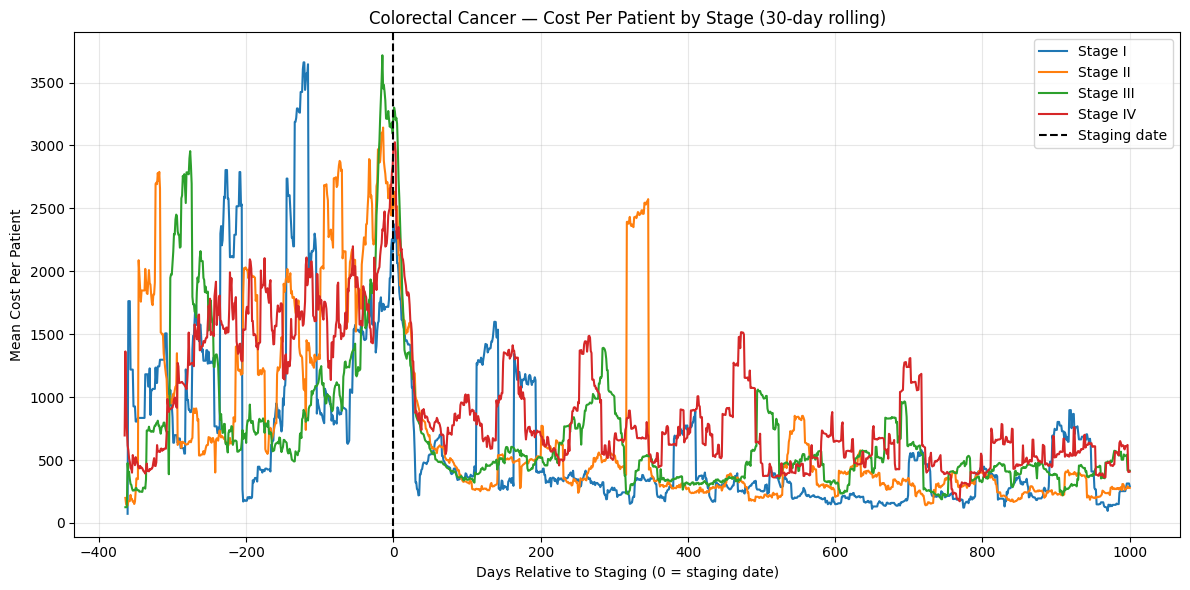

In [34]:
import matplotlib.pyplot as plt

pivot_cost = grouped.pivot_table(
    index='days_from_stage',
    columns='final_stage_simple',
    values='cost_per_patient'
)

pivot_cost = pivot_cost[(pivot_cost.index >= -365) & (pivot_cost.index <= 1000)]
pivot_rolling = pivot_cost.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12, 6))
for stage in pivot_rolling.columns:
    plt.plot(pivot_rolling.index, pivot_rolling[stage], label=f'Stage {stage}')

plt.axvline(0, linestyle='--', color='black', label='Staging date')
plt.title('Colorectal Cancer — Cost Per Patient by Stage (30-day rolling)')
plt.xlabel('Days Relative to Staging (0 = staging date)')
plt.ylabel('Mean Cost Per Patient')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

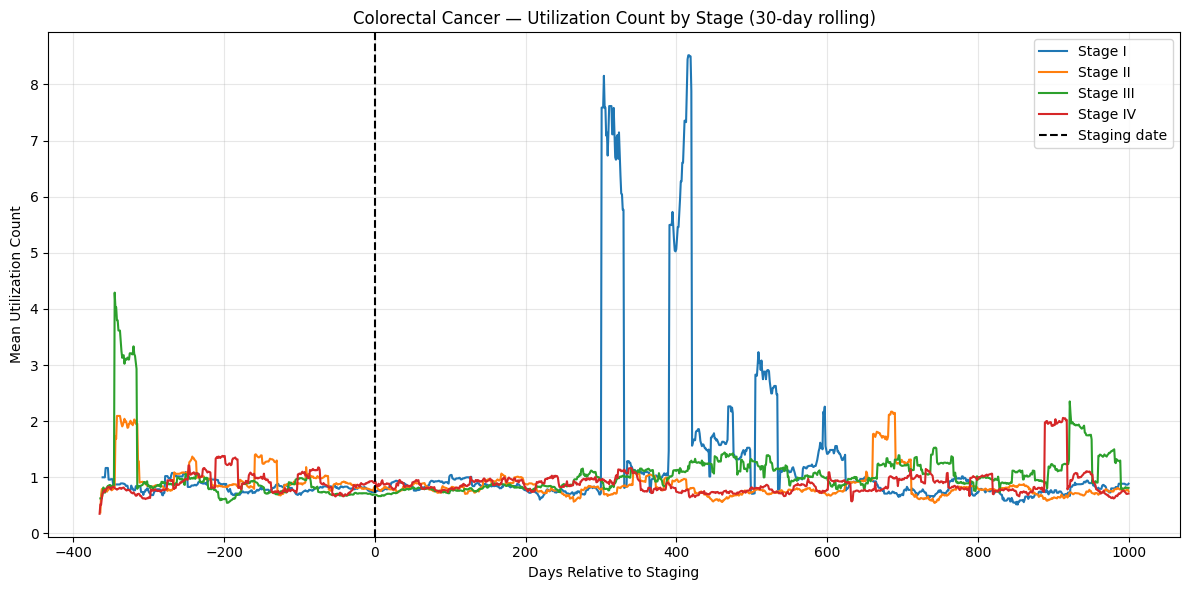

In [35]:
pivot_util = grouped.pivot_table(
    index='days_from_stage',
    columns='final_stage_simple',
    values='mean_utilization'
)

pivot_util = pivot_util[(pivot_util.index >= -365) & (pivot_util.index <= 1000)]
pivot_util_rolling = pivot_util.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12, 6))
for stage in pivot_util_rolling.columns:
    plt.plot(pivot_util_rolling.index, pivot_util_rolling[stage], label=f'Stage {stage}')

plt.axvline(0, linestyle='--', color='black', label='Staging date')
plt.title('Colorectal Cancer — Utilization Count by Stage (30-day rolling)')
plt.xlabel('Days Relative to Staging')
plt.ylabel('Mean Utilization Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Unique providers per stage
provider_by_stage = (
    colorectal
    .groupby('final_stage_simple')
    .agg(
        unique_providers=('provider_number', 'nunique'),
        unique_members=('member_number', 'nunique'),
        total_claims=('member_number', 'count')
    )
    .reset_index()
)

provider_by_stage['claims_per_member'] = provider_by_stage['total_claims'] / provider_by_stage['unique_members']
provider_by_stage['providers_per_member'] = provider_by_stage['unique_providers'] / provider_by_stage['unique_members']

print("=== Provider Summary by Stage ===")
print(provider_by_stage.to_string(index=False))

# Top providers by claim volume
print("\n=== Top 15 Providers by Claim Volume (Colorectal) ===")
top_providers = (
    colorectal
    .groupby('provider_number')
    .agg(
        claim_count=('member_number', 'count'),
        unique_members=('member_number', 'nunique'),
        total_cost=('c_allowed', 'sum'),
        mean_cost=('c_allowed', 'mean')
    )
    .reset_index()
    .sort_values('claim_count', ascending=False)
    .head(15)
)
print(top_providers.to_string(index=False))

=== Provider Summary by Stage ===
final_stage_simple  unique_providers  unique_members  total_claims  claims_per_member  providers_per_member
                 I               281              90          6881          76.455556              3.122222
                II               430             182         19150         105.219780              2.362637
               III               642             313         53777         171.811502              2.051118
                IV               427             114         36159         317.184211              3.745614

=== Top 15 Providers by Claim Volume (Colorectal) ===
 provider_number  claim_count  unique_members   total_cost  mean_cost
          2244.0        13955             484 3.790735e+06 271.639941
          2236.0         9345             343 6.269387e+06 670.881472
          2283.0         5945             148 1.881441e+06 316.474517
          7817.0         5935             189 7.878531e+05 132.746934
          2281.0     

In [37]:
colorectal['phase'] = np.where(
    colorectal['days_from_stage'] < 0, 'pre_staging',
    np.where(colorectal['days_from_stage'] <= 180, 'early_post',
    np.where(colorectal['days_from_stage'] <= 1000, 'continuing', 'late'))
)

provider_phase = (
    colorectal
    .groupby(['final_stage_simple', 'phase'])
    .agg(
        unique_providers=('provider_number', 'nunique'),
        unique_members=('member_number', 'nunique'),
        mean_cost=('c_allowed', 'mean')
    )
    .reset_index()
)

provider_phase['providers_per_member'] = (
    provider_phase['unique_providers'] / provider_phase['unique_members']
)

print("=== Providers Per Member by Stage & Phase ===")
print(provider_phase.pivot_table(
    index='final_stage_simple',
    columns='phase',
    values='providers_per_member'
).round(2).to_string())

=== Providers Per Member by Stage & Phase ===
phase               continuing  early_post  late  pre_staging
final_stage_simple                                           
I                         1.38        1.70  1.34         2.32
II                        1.21        1.55  1.07         1.88
III                       1.13        1.26  0.82         1.58
IV                        1.93        2.02  2.55         3.01


In [38]:
# Drug frequency by stage
drug_by_stage = (
    colorectal[colorectal['DRUG_NM'].notna()]
    .groupby(['final_stage_simple', 'DRUG_NM'])
    .agg(
        claim_count=('member_number', 'count'),
        unique_members=('member_number', 'nunique'),
        total_cost=('c_allowed', 'sum'),
        mean_cost=('c_allowed', 'mean')
    )
    .reset_index()
    .sort_values(['final_stage_simple', 'claim_count'], ascending=[True, False])
)

print("=== Top 10 Drugs Per Stage (Colorectal) ===")
for stage in ['I', 'II', 'III', 'IV']:
    subset = drug_by_stage[drug_by_stage['final_stage_simple'] == stage].head(10)
    if not subset.empty:
        print(f"\n--- Stage {stage} ---")
        print(subset[['DRUG_NM', 'claim_count', 'unique_members', 'mean_cost']].to_string(index=False))

=== Top 10 Drugs Per Stage (Colorectal) ===

--- Stage I ---
               DRUG_NM  claim_count  unique_members    mean_cost
                                580              62   119.618152
          CAPECITABINE           20               1   416.594000
         METRONIDAZOLE            5               5     1.598147
PROCHLORPERAZINE MALEA            4               3    20.125622
            GABAPENTIN            3               2    16.386709
      NEOMYCIN SULFATE            3               3     7.190975
              VERZENIO            3               1 13180.363333
DIPHENOXYLATE-ATROPINE            2               1    25.670000
         OXYCODONE HCL            1               1    12.870000
                SUPREP            1               1   103.060000

--- Stage II ---
               DRUG_NM  claim_count  unique_members   mean_cost
                               1949             139  103.069800
PROCHLORPERAZINE MALEA           34              20   23.015837
         OXYCO

In [39]:
# NDC frequency by stage
ndc_by_stage = (
    colorectal[colorectal['NDC_CD'].notna()]
    .groupby(['final_stage_simple', 'NDC_CD'])
    .agg(
        claim_count=('member_number', 'count'),
        unique_members=('member_number', 'nunique'),
        total_cost=('c_allowed', 'sum')
    )
    .reset_index()
    .sort_values(['final_stage_simple', 'claim_count'], ascending=[True, False])
)

print("=== Top 10 NDC Codes Per Stage (Colorectal) ===")
for stage in ['I', 'II', 'III', 'IV']:
    subset = ndc_by_stage[ndc_by_stage['final_stage_simple'] == stage].head(10)
    if not subset.empty:
        print(f"\n--- Stage {stage} ---")
        print(subset[['NDC_CD', 'claim_count', 'unique_members', 'total_cost']].to_string(index=False))

=== Top 10 NDC Codes Per Stage (Colorectal) ===

--- Stage I ---
       NDC_CD  claim_count  unique_members   total_cost
00270-1316-35           68              31  1180.255448
63323-0269-29           25              21    22.940000
00019-4816-04           17              12    15.100000
00270-1315-35           16               7     0.000000
00270-1316-95           16              11   149.835071
00338-0117-04           16              15    62.250000
16729-0332-05           12               1   418.000000
55513-0206-01           12               1 24764.100000
63323-0117-61           12               3   270.731597
25021-0215-99           11               2   405.647641

--- Stage II ---
       NDC_CD  claim_count  unique_members  total_cost
00270-1316-35          187              78 1112.713289
63323-0117-61           91              18 1979.039322
16729-0276-38           73              19 1590.990000
25021-0215-99           54              13 1274.041044
00270-1316-30           53

In [40]:
drug_time = (
    colorectal[colorectal['DRUG_NM'].notna()]
    .groupby(['final_stage_simple', 'phase', 'DRUG_NM'])
    .agg(
        claim_count=('member_number', 'count'),
        total_cost=('c_allowed', 'sum'),
        mean_cost=('c_allowed', 'mean')
    )
    .reset_index()
    .sort_values(['final_stage_simple', 'phase', 'claim_count'], ascending=[True, True, False])
)

print("=== Top 5 Drugs by Phase & Stage ===")
for stage in ['I', 'II', 'III', 'IV']:
    print(f"\n{'='*40}\nStage {stage}")
    for phase in ['pre_staging', 'early_post', 'continuing', 'late']:
        subset = drug_time[
            (drug_time['final_stage_simple'] == stage) &
            (drug_time['phase'] == phase)
        ].tail(5)
        if not subset.empty:
            print(f"\n  [{phase}]")
            print(subset[['DRUG_NM', 'claim_count', 'mean_cost']].to_string(index=False))

=== Top 5 Drugs by Phase & Stage ===

Stage I

  [pre_staging]
               DRUG_NM  claim_count  mean_cost
                                290  73.670226
         METRONIDAZOLE            5   1.598147
      NEOMYCIN SULFATE            3   7.190975
PROCHLORPERAZINE MALEA            2  23.691244

  [early_post]
               DRUG_NM  claim_count  mean_cost
                                123 254.984153
DIPHENOXYLATE-ATROPINE            2  25.670000
            GABAPENTIN            1   4.630000

  [continuing]
               DRUG_NM  claim_count  mean_cost
            GABAPENTIN            2  22.265064
PROCHLORPERAZINE MALEA            2  16.560000
         OXYCODONE HCL            1  12.870000
                SUPREP            1 103.060000
                 SUTAB            1 152.030000

  [late]
 DRUG_NM  claim_count    mean_cost
                   39     6.868526
VERZENIO            3 13180.363333

Stage II

  [pre_staging]
               DRUG_NM  claim_count  mean_cost
  LIDOCAINE

In [41]:
patient_colorectal = (
    colorectal
    .groupby(['member_number', 'final_stage_simple', 'cancer_type'])
    .agg(
        total_cost=('c_allowed', 'sum'),
        total_claims=('member_number', 'count'),
        unique_providers=('provider_number', 'nunique'),
        unique_drugs=('DRUG_NM', 'nunique'),
        unique_ndc=('NDC_CD', 'nunique'),
        followup_days=('days_since_earliest_dt', 'max'),
        time_to_stage=('most_recent_stage_date', 'first')
    )
    .reset_index()
)

print("Patient-Level Summary by Stage")
print(
    patient_colorectal
    .groupby('final_stage_simple')
    .agg(
        n_patients=('member_number', 'count'),
        mean_total_cost=('total_cost', 'mean'),
        median_total_cost=('total_cost', 'median'),
        mean_claims=('total_claims', 'mean'),
        mean_providers=('unique_providers', 'mean'),
        mean_unique_drugs=('unique_drugs', 'mean'),
        mean_followup=('followup_days', 'mean'),
        mean_time_to_stage=('time_to_stage', 'mean')
    )
    .round(2)
    .to_string()
)

Patient-Level Summary by Stage
                    n_patients  mean_total_cost  median_total_cost  mean_claims  mean_providers  mean_unique_drugs  mean_followup  mean_time_to_stage
final_stage_simple                                                                                                                                   
I                           90         25097.13           21920.46        76.46            7.23               0.90        1143.11              124.44
II                         182         29714.60           25364.24       105.22            8.05               1.21         966.12               11.03
III                        313         43307.64           39029.97       171.81            9.88               1.66        1110.88                0.52
IV                         114        103183.00           60712.98       317.18           11.86               2.09        1038.74              319.91


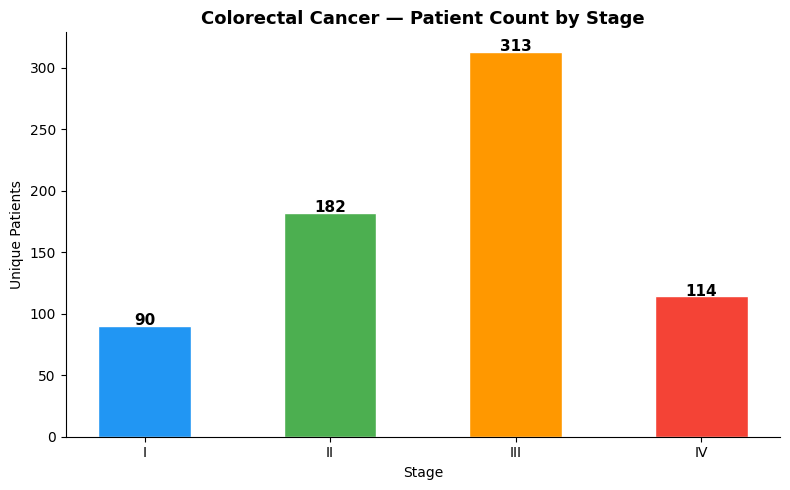

✅ Saved 1_patient_count_by_stage.png


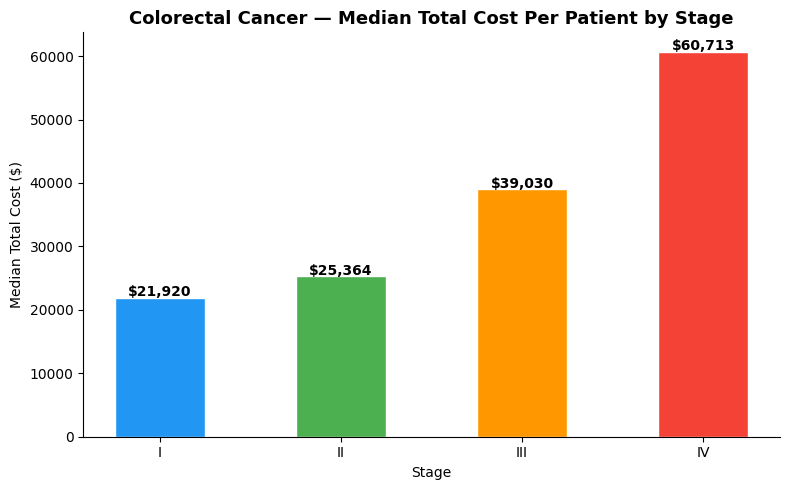

✅ Saved 2_median_cost_by_stage.png


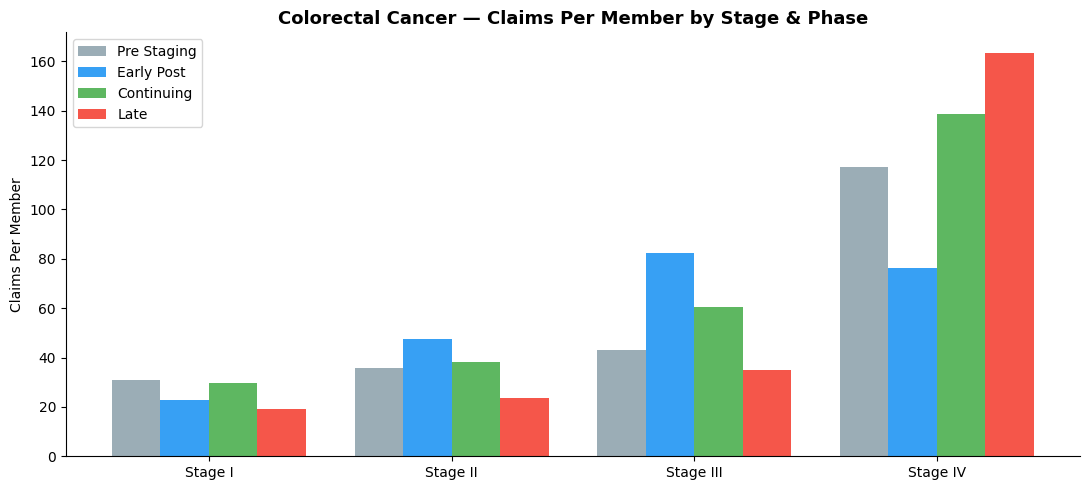

✅ Saved 3_claims_per_member_by_phase.png


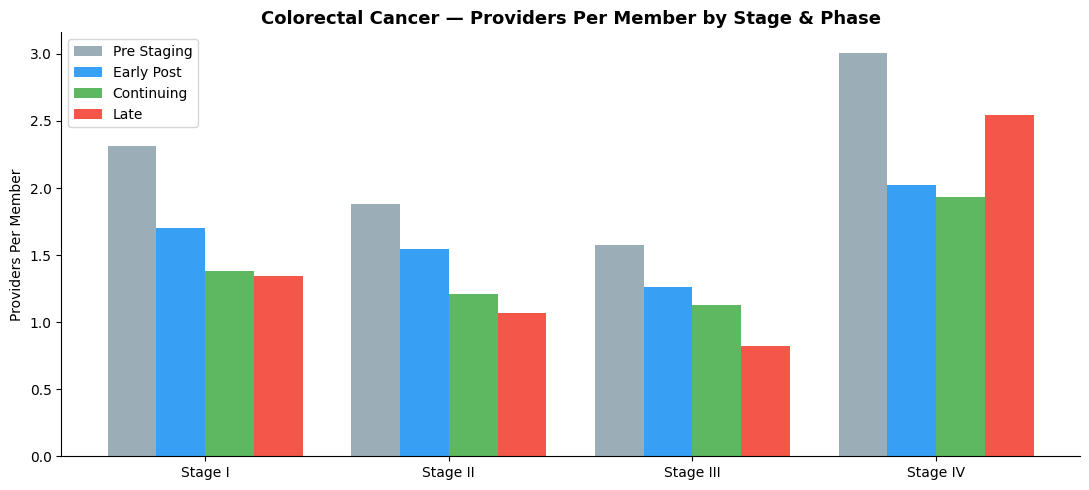

✅ Saved 4_providers_per_member.png


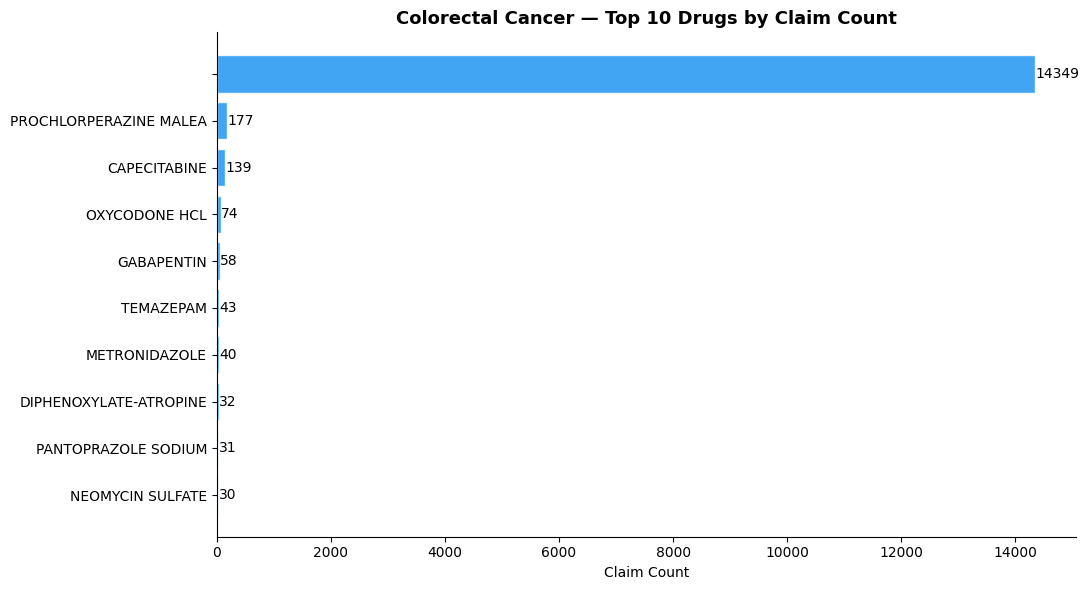

✅ Saved 5_top_drugs.png


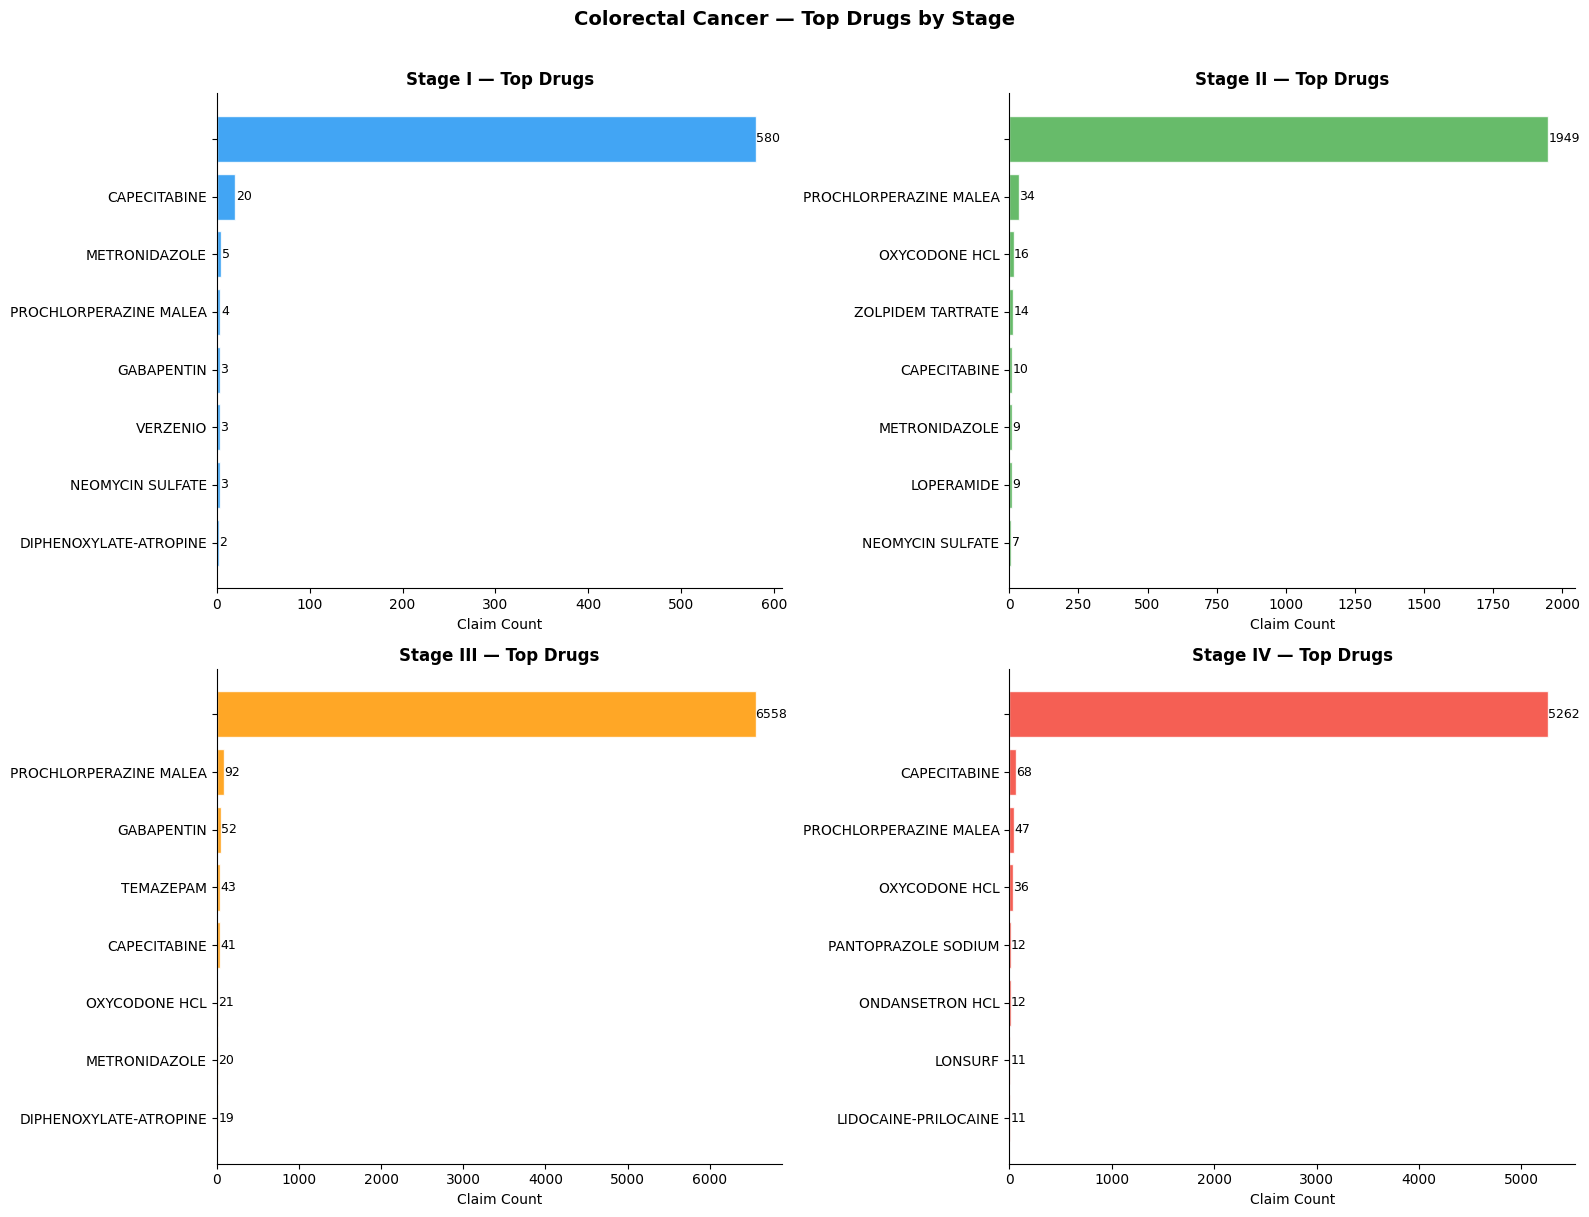

✅ Saved 6_top_drugs_by_stage.png


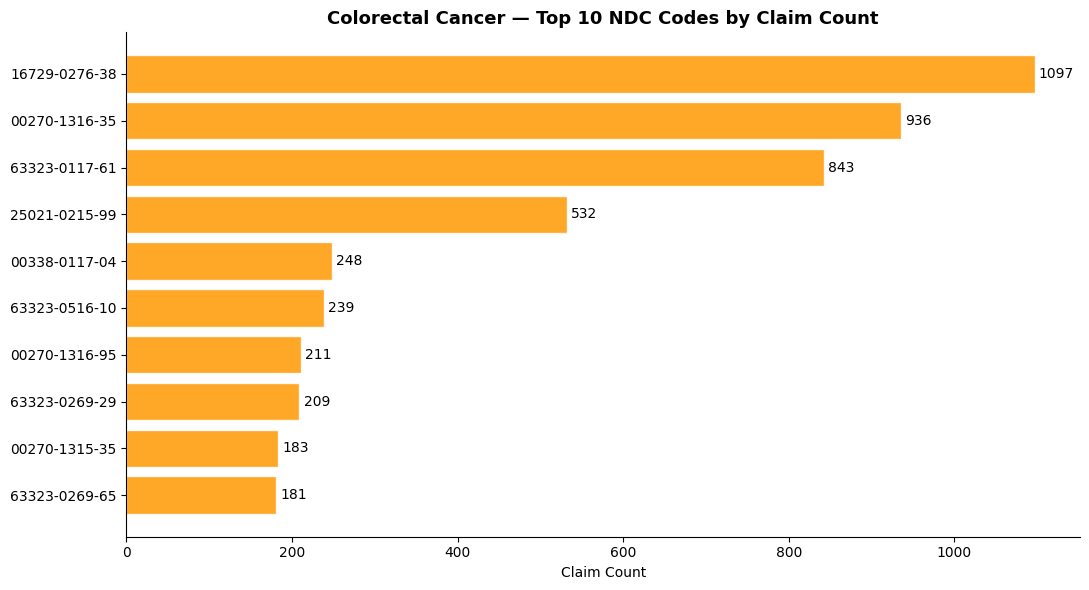

✅ Saved 7_top_ndc_codes.png


In [45]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {'I': '#2196F3', 'II': '#4CAF50', 'III': '#FF9800', 'IV': '#F44336'}
PHASE_COLORS = {'pre_staging': '#90A4AE', 'early_post': '#2196F3', 'continuing': '#4CAF50', 'late': '#F44336'}

def save(name):
    plt.tight_layout()
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved {name}.png')

# ── 1. Patient Count by Stage ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
stage_counts = colorectal.groupby('final_stage_simple')['member_number'].nunique().reindex(['I','II','III','IV'])
bars = ax.bar(stage_counts.index, stage_counts.values, color=[COLORS[s] for s in stage_counts.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, stage_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Colorectal Cancer — Patient Count by Stage', fontsize=13, fontweight='bold')
ax.set_xlabel('Stage')
ax.set_ylabel('Unique Patients')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('1_patient_count_by_stage')

# ── 2. Median Total Cost Per Patient by Stage ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cost_by_stage = patient_colorectal.groupby('final_stage_simple')['total_cost'].median().reindex(['I','II','III','IV'])
bars = ax.bar(cost_by_stage.index, cost_by_stage.values, color=[COLORS[s] for s in cost_by_stage.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, cost_by_stage.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Colorectal Cancer — Median Total Cost Per Patient by Stage', fontsize=13, fontweight='bold')
ax.set_xlabel('Stage')
ax.set_ylabel('Median Total Cost ($)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('2_median_cost_by_stage')

# ── 3. Claims Per Member by Stage & Phase ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
claims_phase = (
    colorectal
    .groupby(['final_stage_simple', 'phase'])
    .agg(claims=('member_number', 'count'), members=('member_number', 'nunique'))
    .reset_index()
)
claims_phase['claims_per_member'] = claims_phase['claims'] / claims_phase['members']
pivot_cpm = claims_phase.pivot_table(index='final_stage_simple', columns='phase', values='claims_per_member')
pivot_cpm = pivot_cpm.reindex(index=['I','II','III','IV'], columns=['pre_staging', 'early_post', 'continuing', 'late'])
x = np.arange(len(pivot_cpm.index))
width = 0.2
for i, phase in enumerate(['pre_staging', 'early_post', 'continuing', 'late']):
    if phase in pivot_cpm.columns:
        ax.bar(x + i * width, pivot_cpm[phase].fillna(0), width, label=phase.replace('_', ' ').title(), color=PHASE_COLORS[phase], alpha=0.9)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Stage {s}' for s in pivot_cpm.index])
ax.set_title('Colorectal Cancer — Claims Per Member by Stage & Phase', fontsize=13, fontweight='bold')
ax.set_ylabel('Claims Per Member')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('3_claims_per_member_by_phase')

# ── 4. Providers Per Member by Stage & Phase ─────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ppm = provider_phase.pivot_table(index='final_stage_simple', columns='phase', values='providers_per_member')
ppm = ppm.reindex(index=['I','II','III','IV'], columns=['pre_staging', 'early_post', 'continuing', 'late'])
x = np.arange(len(ppm.index))
for i, phase in enumerate(['pre_staging', 'early_post', 'continuing', 'late']):
    if phase in ppm.columns:
        ax.bar(x + i * width, ppm[phase].fillna(0), width, label=phase.replace('_', ' ').title(), color=PHASE_COLORS[phase], alpha=0.9)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Stage {s}' for s in ppm.index])
ax.set_title('Colorectal Cancer — Providers Per Member by Stage & Phase', fontsize=13, fontweight='bold')
ax.set_ylabel('Providers Per Member')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('4_providers_per_member')

# ── 5. Top 10 Drugs by Claim Count ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
top_drugs = (
    colorectal[colorectal['DRUG_NM'].notna()]
    .groupby('DRUG_NM')['member_number'].count()
    .sort_values(ascending=True)
    .tail(10)
)
bars = ax.barh(top_drugs.index, top_drugs.values, color='#2196F3', alpha=0.85, edgecolor='white')
for i, val in enumerate(top_drugs.values):
    ax.text(val + 5, i, str(val), va='center', fontsize=10)
ax.set_title('Colorectal Cancer — Top 10 Drugs by Claim Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Claim Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('5_top_drugs')

# ── 6. Top 10 Drugs by Stage (grouped) ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, stage in enumerate(['I', 'II', 'III', 'IV']):
    ax = axes[idx]
    top = (
        colorectal[
            (colorectal['DRUG_NM'].notna()) &
            (colorectal['final_stage_simple'] == stage)
        ]
        .groupby('DRUG_NM')['member_number'].count()
        .sort_values(ascending=True)
        .tail(8)
    )
    ax.barh(top.index, top.values, color=COLORS[stage], alpha=0.85, edgecolor='white')
    for i, val in enumerate(top.values):
        ax.text(val + 1, i, str(val), va='center', fontsize=9)
    ax.set_title(f'Stage {stage} — Top Drugs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Claim Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Colorectal Cancer — Top Drugs by Stage', fontsize=14, fontweight='bold', y=1.01)
save('6_top_drugs_by_stage')

# ── 7. Top 10 NDC Codes by Claim Count ───────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
top_ndc = (
    colorectal[colorectal['NDC_CD'].notna()]
    .groupby('NDC_CD')['member_number'].count()
    .sort_values(ascending=True)
    .tail(10)
)
ax.barh(top_ndc.index.astype(str), top_ndc.values, color='#FF9800', alpha=0.85, edgecolor='white')
for i, val in enumerate(top_ndc.values):
    ax.text(val + 5, i, str(val), va='center', fontsize=10)
ax.set_title('Colorectal Cancer — Top 10 NDC Codes by Claim Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Claim Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save('7_top_ndc_codes')